In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b7= bd.iloc[115]

In [4]:
b7['datetime']

'2020-08-19,15:03:42.449837+00:00'

In [5]:
lat= literal_eval(b7['lat_stereo_g17'])
long= literal_eval(b7['lon_stereo_g17'])
alt= literal_eval(b7['alt_stereo_g17'])
energy = literal_eval(b7['energyJoules_stereo_g17'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

37 37 37 37


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

24


In [9]:
totalmass= 0
totalh= 0 
for i in range (24): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.00022466925144518378 0.0001048456506744191 0.001048456506744191


In [11]:
totalh

9437.693583016431

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.0014780800000124827
0.0012484399999976858
0.0008546799999891164
0.28447723000000735
0.0904873399999957
0.10893372000001023
0.018490389999996637
0.07838669000000209
0.2154037099999897
-0.00018109999999182946
-0.0004443400000013753
-0.0008759699999956183
-0.00023932000000570497
0.0007742600000000266
0.0010013899999989917
0.0012646400000022595
0.0010716500000000906
0.0010707699999983333
-0.0016008799999980283
-0.001397800000006555
-0.001005689999999504
-0.0007886399999961213
-0.0005841300000071215
0.0012468700000027866
0.0012367799999992712
-7.980999998835614e-05
-0.0003069300000078101
-0.00029542999999421227
-8.299000000988599e-05
-8.298999999567513e-05
0.0002384900000009793
-0.0006659200000029841
-0.0006494200000020101
-0.0008429399999982934
-0.0006379099999946902
0.002222799999998415


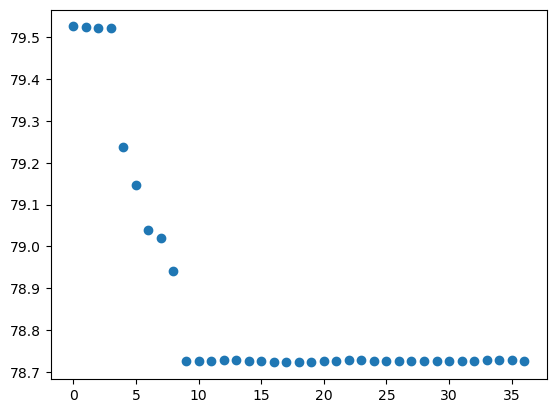

In [13]:
plt.scatter(range(len(alt)), alt)